In [1]:
%load_ext autoreload
%autoreload 2

from plonk.pipe import PlonkPipeline
from PIL import Image
from pathlib import Path
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize


device = torch.device("cuda")

/home/charles/miniforge3/envs/plonk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading Model

In [2]:
# pipeline = PlonkPipeline("local_models/StreetCLIP_Multi_Mean_Model").to(device)

## Using a specific image

In [3]:
pipeline = PlonkPipeline("local_models/my_plonk_model").to(device)
image_path = "demo/examples/santa_clara.jpg"
output_path = "demo/results/santa_clara.pdf"
image = Image.open(image_path)

Loading weights from local directory


In [36]:
gps_coords = pipeline(image, batch_size=1024)

In [37]:
latitude, longitude, likelihood = pipeline.compute_likelihood_grid(image, grid_resolution_deg=1, batch_size=4096, cfg=0)

Computing likelihood over a 181x361 grid (65341 points)...


Computing Likelihood Grid:   0%|          | 0/16 [00:00<?, ?it/s]

Computing Likelihood Grid:   6%|▋         | 1/16 [01:11<17:56, 71.76s/it]

Likelihood NFE: 1904


Computing Likelihood Grid:  12%|█▎        | 2/16 [02:23<16:44, 71.78s/it]

...

Likelihood NFE: 1736


Computing Likelihood Grid:  94%|█████████▍| 15/16 [18:02<01:05, 65.61s/it]

Likelihood NFE: 1544


Computing Likelihood Grid: 100%|██████████| 16/16 [18:52<00:00, 70.79s/it]

Likelihood NFE: 1430


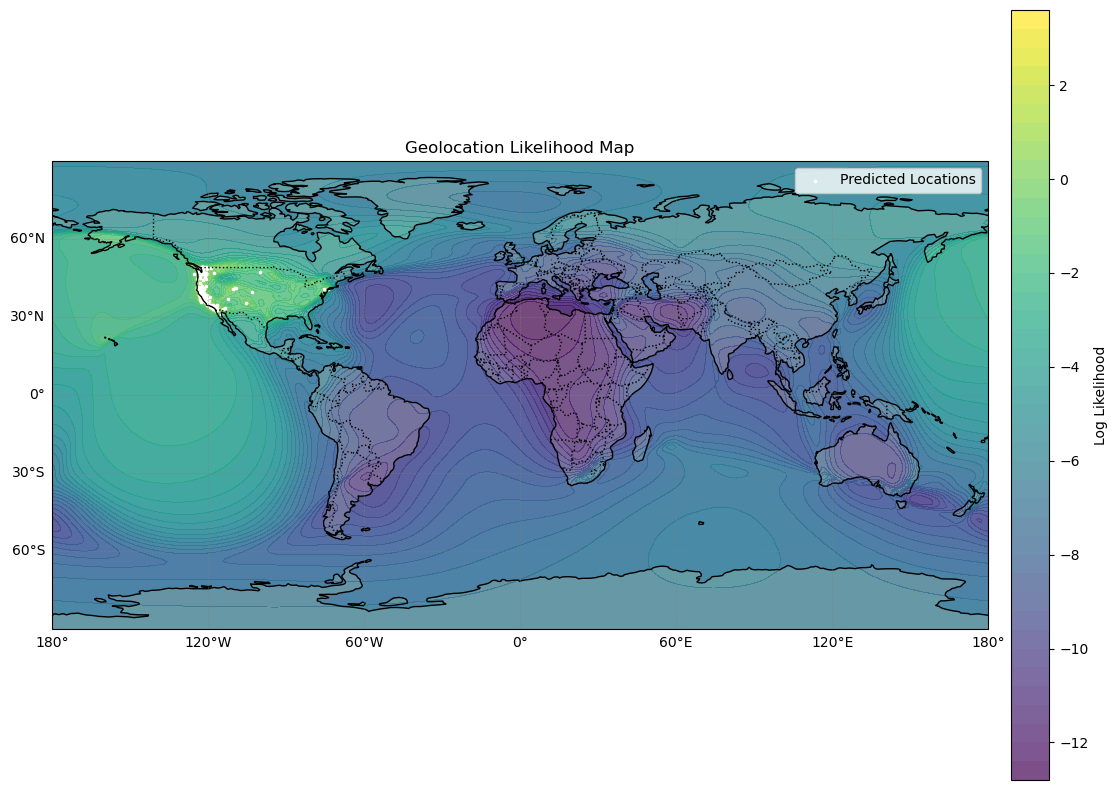

In [38]:
# Create a figure with a map projection
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Create a mesh grid for the contour plot
lon_mesh, lat_mesh = np.meshgrid(longitude, latitude)

# Normalize the likelihood values for better visualization
# Higher values should be more prominent
norm = Normalize(vmin=likelihood.min(), vmax=likelihood.max())

# Create a filled contour plot of the likelihood values
contour = ax.contourf(lon_mesh, lat_mesh, likelihood, 
                      transform=ccrs.PlateCarree(),
                      cmap='viridis', norm=norm, levels=50, alpha=0.7)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Log Likelihood')

# Mark the predicted GPS coordinates
ax.scatter(gps_coords[:, 1], gps_coords[:, 0], 
           color='white', marker='.', s=10, 
           transform=ccrs.PlateCarree(), 
           label='Predicted Locations')

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Add title and legend
plt.title('Geolocation Likelihood Map')
plt.legend()

# Show the plot
plt.tight_layout()
plt.savefig(output_path)
plt.show()


In [39]:
# Compute localizability
localizability = pipeline.compute_localizability(image)
print(f"Localizability: {localizability}")

/home/charles/code/EECE5639_Final_Project_Fork/plonk/models/samplers/riemannian_flow_sampler.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):


Likelihood NFE: 1124
Localizability: 0.7498285174369812


## Using Multiple Images combination

In [6]:
pipeline = PlonkPipeline("local_models/StreetCLIP_Multi_Att_Model").to(device)
image_dir = "demo/examples/proximity_batches/batch_4"
output_path_comparison = "demo/results/russia_forest_single_vs_multi_comparison_att_t1.pdf"
anchor_path = Path(image_dir) / "anchor.jpg"
neighbor_paths = sorted(p for p in Path(image_dir).glob("*.jpg") if p.name != "anchor.jpg")
entries = [[Image.open(anchor_path)] + [Image.open(p) for p in neighbor_paths]]

Loading weights from local directory


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 59711.37it/s]
CLIPVisionModel LOAD REPORT from: geolocal/StreetCLIP
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.final_layer_norm.bias                             | UNEXPECTED | 

In [7]:
gps_coords = pipeline(entries, batch_size=1024)
latitude, longitude, likelihood = pipeline.compute_likelihood_grid(
    entries, grid_resolution_deg=1, batch_size=4096, cfg=0
)

# Single-image baseline: run the pipeline on just the anchor image
single_image = Image.open(Path(image_dir) / "anchor.jpg")

single_gps = pipeline(single_image, batch_size=1024)
single_lat, single_lon, single_likelihood = pipeline.compute_likelihood_grid(
    single_image, grid_resolution_deg=1, batch_size=4096, cfg=0
)

Computing likelihood over a 181x361 grid (65341 points)...


Computing Likelihood Grid:   6%|▋         | 1/16 [00:30<07:43, 30.92s/it]

Likelihood NFE: 830


Computing Likelihood Grid:  12%|█▎        | 2/16 [01:02<07:19, 31.41s/it]

Likelihood NFE: 842


...

Likelihood NFE: 830


Computing Likelihood Grid:  94%|█████████▍| 15/16 [07:52<00:32, 32.30s/it]

Likelihood NFE: 914


Computing Likelihood Grid: 100%|██████████| 16/16 [08:27<00:00, 31.73s/it]

Likelihood NFE: 938


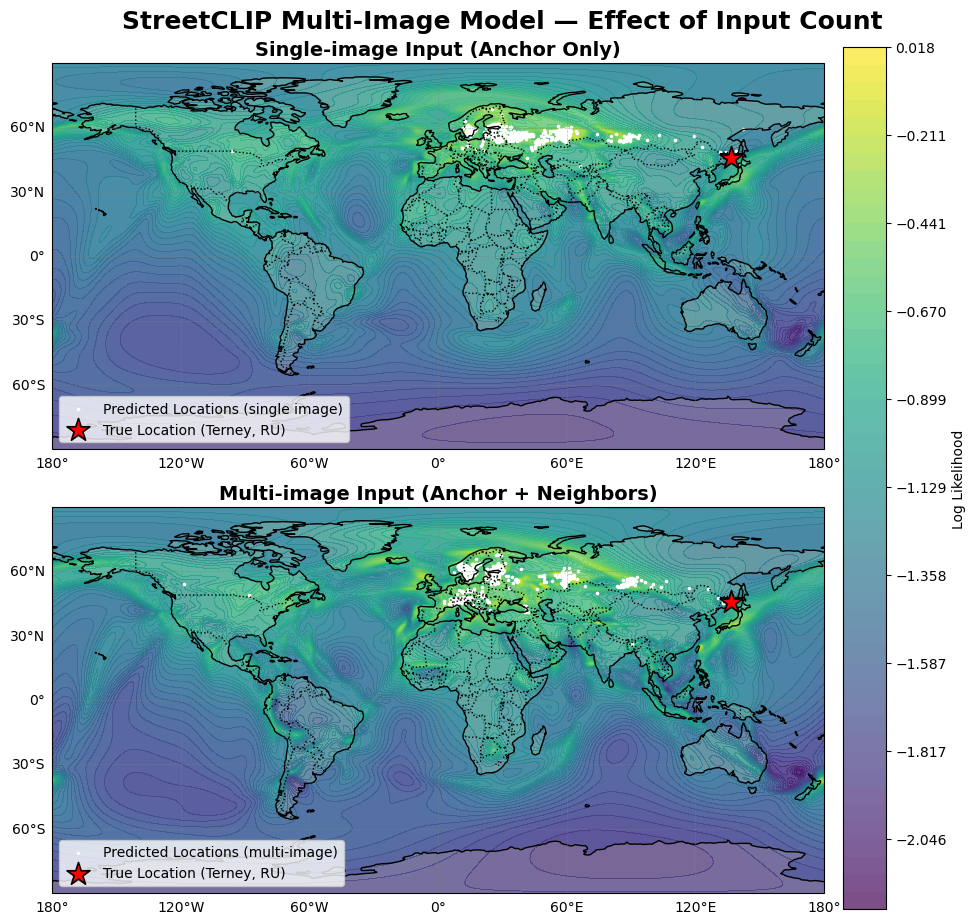

In [8]:
with open(Path(image_dir) / "anchor_location.json") as f:
    truth = json.load(f)
true_lat, true_lon = truth["latitude"], truth["longitude"]

vmin = min(single_likelihood.min(), likelihood.min())
vmax = max(single_likelihood.max(), likelihood.max())
norm = Normalize(vmin=vmin, vmax=vmax)
levels = np.linspace(vmin, vmax, 50)

fig, axes = plt.subplots(
    2, 1, figsize=(12, 14),
    subplot_kw={"projection": ccrs.PlateCarree()},
    gridspec_kw={"hspace": -0.3},
)

fig.suptitle(
    "StreetCLIP Multi-Image Model — Effect of Input Count",
    fontsize=18, fontweight="bold", y=0.83,
)

panels = [
    ("Single-image Input (Anchor Only)",
     single_lon, single_lat, single_likelihood, single_gps,
     "Predicted Locations (single image)"),
    ("Multi-image Input (Anchor + Neighbors)",
     longitude, latitude, likelihood, gps_coords,
     "Predicted Locations (multi-image)"),
]

for ax, (title, lon, lat, like, gps, pred_label) in zip(axes, panels):
    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")

    lon_mesh, lat_mesh = np.meshgrid(lon, lat)
    contour = ax.contourf(lon_mesh, lat_mesh, like,
                          transform=ccrs.PlateCarree(),
                          cmap="viridis", norm=norm, levels=levels, alpha=0.7)

    ax.scatter(gps[:, 1], gps[:, 0],
               color="white", marker=".", s=10,
               transform=ccrs.PlateCarree(),
               label=pred_label)

    ax.scatter([true_lon], [true_lat],
               color="red", marker="*", s=300, edgecolor="black", linewidth=1.2,
               transform=ccrs.PlateCarree(), zorder=5,
               label=f"True Location ({truth.get('city','')}, {truth.get('country','')})")

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend(loc="lower left")

cbar = fig.colorbar(contour, ax=axes, orientation="vertical", pad=0.02, shrink=0.8)
cbar.set_label("Log Likelihood")

fig.savefig(output_path_comparison, bbox_inches="tight")
plt.show()

Comparing the anchor image to the single image trained StreetCLIP model

In [44]:
pipeline = PlonkPipeline("local_models/my_plonk_model").to(device)
output_path_single_image = "demo/results/russia_forest_StreetCLIP_Single_Image_Model.pdf"

Loading weights from local directory


In [ ]:
# Single-image baseline: run the pipeline on just the anchor image
single_image = Image.open(Path(image_dir) / "anchor.jpg")

single_gps = pipeline(single_image, batch_size=1024)
single_lat, single_lon, single_likelihood = pipeline.compute_likelihood_grid(
    single_image, grid_resolution_deg=1, batch_size=4096, cfg=0
)

In [ ]:
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

lon_mesh, lat_mesh = np.meshgrid(single_lon, single_lat)
norm = Normalize(vmin=single_likelihood.min(), vmax=single_likelihood.max())
contour = ax.contourf(lon_mesh, lat_mesh, single_likelihood,
                      transform=ccrs.PlateCarree(),
                      cmap="viridis", norm=norm, levels=50, alpha=0.7)
cbar = plt.colorbar(contour, ax=ax, orientation="vertical", pad=0.02, shrink=0.6)
cbar.set_label("Log Likelihood")

ax.scatter(single_gps[:, 1], single_gps[:, 0],
           color="white", marker=".", s=10,
           transform=ccrs.PlateCarree(),
           label="Predicted Locations (single image)")

ax.scatter([true_lon], [true_lat],
           color="red", marker="*", s=300, edgecolor="black", linewidth=1.2,
           transform=ccrs.PlateCarree(), zorder=5,
           label=f"True Location ({truth.get('city','')}, {truth.get('country','')})")

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

plt.title(f"StreetCLIP Single-image Geolocation", fontsize=16, fontweight="bold")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(output_path_single_image, bbox_inches="tight")
plt.show()

## Save Video of evolution of model predictions from randomness

In [55]:
image_path = "demo/examples/beacon_hill.png"
image_out = "beacon_hill"
image = Image.open(image_path)

FileNotFoundError: [Errno 2] No such file or directory: 'demo/examples/beacon_hill.png'

/home/charles/code/EECE5639_Final_Project_Fork/plonk/models/samplers/riemannian_flow_sampler.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):


NameError: name 'image_out' is not defined

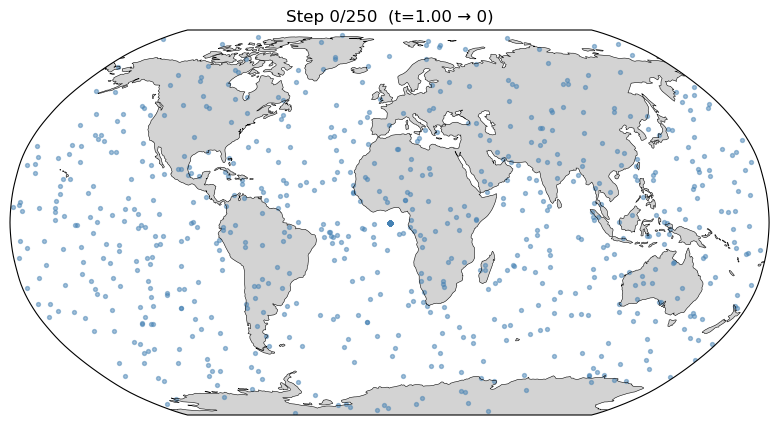

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation

_, traj = pipeline(image, batch_size=1024, return_trajectories=True)

# num_frames = 10
# frame_indices = np.linspace(0, len(traj) - 1, num_frames, dtype=int)
frame_indices = np.arange(len(traj))
num_frames = len(frame_indices)
frames = [traj[i] for i in frame_indices]

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.set_global()

scatter = ax.scatter([], [], s=8, color="steelblue", alpha=0.5,
                     transform=ccrs.PlateCarree())
title = ax.set_title("")

def update(i):
    pts = frames[i]
    scatter.set_offsets(np.c_[pts[:, 1], pts[:, 0]])
    step = frame_indices[i]
    title.set_text(f"Step {step}/{len(traj)-1}  (t={1 - step/(len(traj)-1):.2f} → 0)")
    return scatter, title

ani = FuncAnimation(fig, update, frames=num_frames, interval=600, blit=False)
ani.save(f"demo/diagrams/{image_out}_diffusion_trajectory.mp4", writer="ffmpeg", fps=12, dpi=150)
plt.close()
print("Saved to diffusion_trajectory.mp4")